# Visualize distributions: histograms and density plots
## Single variable distribution
### Histogram

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic_passenger = pd.read_csv("../06-Exploratory_data_analysis/data/Titanic-Dataset.csv")

titanic_passenger.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_passenger['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Text(0.5, 0, 'Age (year)')

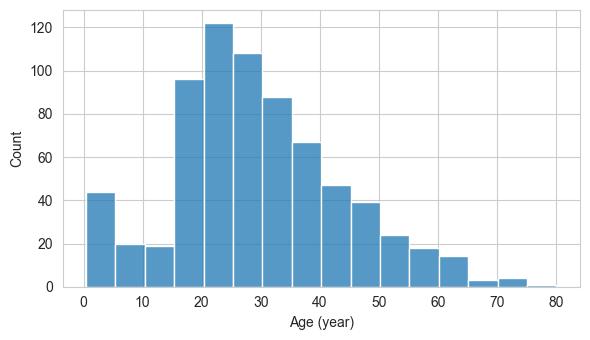

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

sns.histplot(data=titanic_passenger, x='Age', binwidth=5,
             ax=ax)

plt.xlabel("Age (year)")

Histograms are generated by binning the data (see Demo 06-04), so how the figure looks like depends on the bin width.

When making a histogram, always explore multiple bin widths.

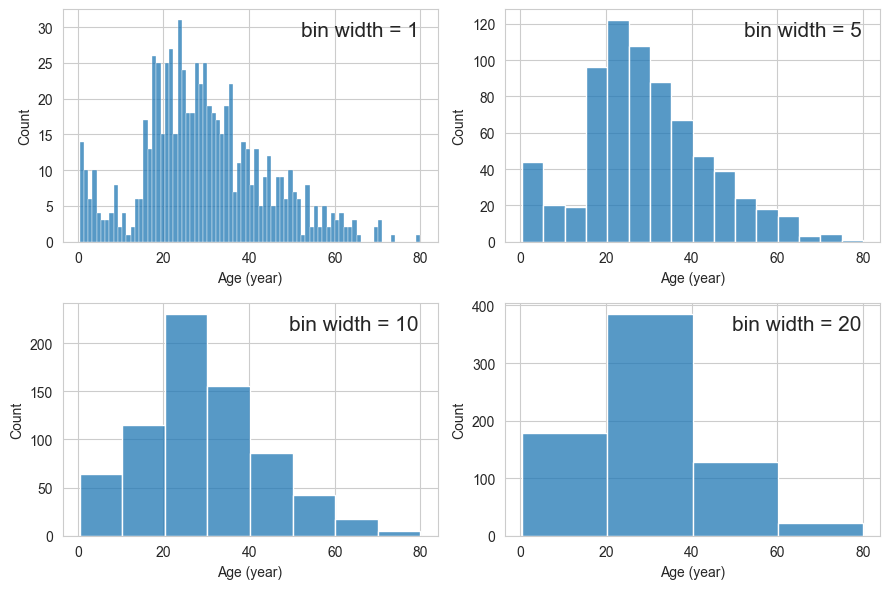

In [28]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9,6), tight_layout=True)

for bin_width, ax in zip([1, 5, 10, 20], axes.flat):
    sns.histplot(data=titanic_passenger, x='Age', binwidth=bin_width, ax=ax)
    ax.set_xlabel("Age (year)")
    ax.text(.95, .95, f'bin width = {bin_width}',
            transform=ax.transAxes, ha='right', va='top', fontsize=15)


### Density plots

"In a density plot, we attempt to visualize the underlying probability distribution of the data by drawing an appropriate continuous curve.

This curve needs to be estimated from the data, and the most commonly used method for this estimation procedure is called _kernel density estimation_. In kernel density estimation, we draw a continuous curve (the kernel) with a small width (controlled by a parameter called _bandwidth_) at the location of each data point, and then we add up all these curves to obtain the final density estimate. The most widely used kernel is a Gaussian kernel (i.e., a Gaussian bell curve), but there are many other choices." (Claus Wilke)

In seaborn, we use kde plots (`sns.kdeplot()` or `sns.displot(kind='kde')` or `sns.histplot(kde=True)`), which stand for kernal density estimation.

Text(0.5, 0, 'Age (year)')

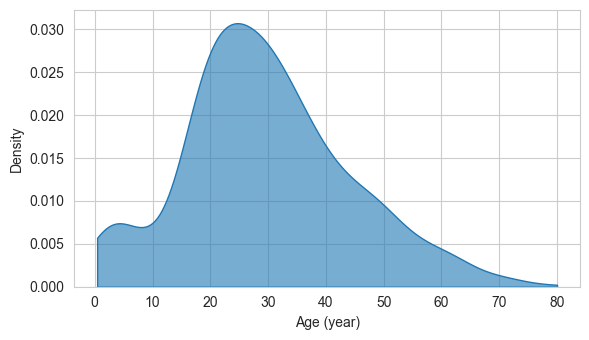

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,3.5), tight_layout=True)

sns.kdeplot(data=titanic_passenger, x='Age',
            fill=True, alpha=0.6,
            bw_adjust=1, # default bw_adjust = 1
            cut=0, # set cut=0 because age cannot be negative
            ax=ax)
ax.set_xlabel("Age (year)")

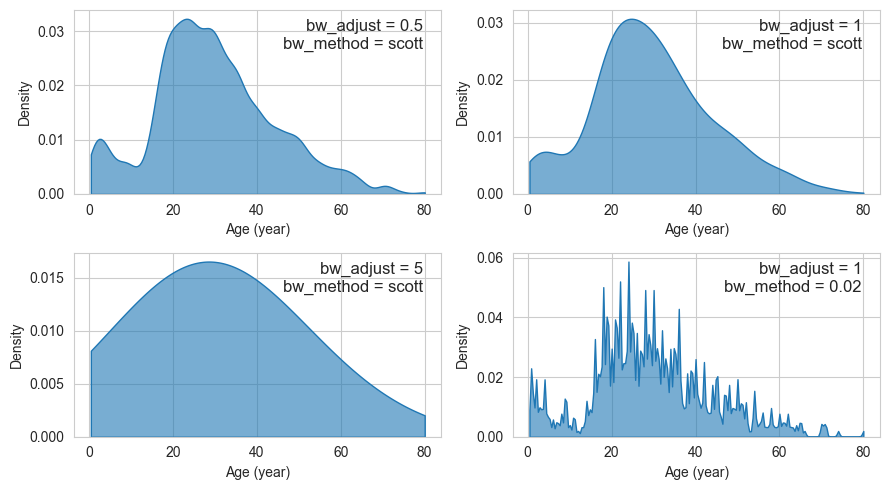

In [58]:
# try adjust the bandwidth

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9,5), tight_layout=True)

for bw_adjust, bw_method, ax in zip([0.5, 1, 5, 1],
                                    ['scott', 'scott', 'scott', 0.02],
                                    axes.flat):
    sns.kdeplot(data=titanic_passenger, x='Age', fill=True,
                alpha=0.6, bw_adjust=bw_adjust, bw_method=bw_method,
                cut=0,ax=ax)
    ax.set_xlabel("Age (year)")
    ax.text(.95, .95, f'bw_adjust = {bw_adjust}\nbw_method = {bw_method}',
            transform=ax.transAxes, ha='right', va='top', fontsize=12)


## Visualize multiple variables' distributions